In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
np.set_printoptions(linewidth=np.inf) #把輸出的寬設成無限大

## 高斯濾波 (二維函數)

$$
G(x, y) = \frac{1}{2\pi\sigma^2} \, e^{-\frac{x^2 + y^2}{2\sigma^2}}
$$


In [3]:
# 產生高斯核
gaussian_size = 3
sigma = 1.0
gaussian_kernel = np.zeros((gaussian_size, gaussian_size))
center = gaussian_size // 2

for i in range(gaussian_size):
    for j in range(gaussian_size):
        x = i - center
        y = j - center
        gaussian_kernel[i, j] = np.exp(-(x**2 + y**2) / (2 * sigma**2))
gaussian_kernel = gaussian_kernel / np.sum(gaussian_kernel)

## 雙邊濾波

In [5]:
image = cv2.imread('Lenna.png', cv2.IMREAD_GRAYSCALE)
h, w = image.shape
diameter = 9
bil_pad = diameter // 2
sigma_s = 9 #空間域的標準差

padded_image5 = np.zeros((h + 2*bil_pad, w + 2*bil_pad))
padded_image5[bil_pad:bil_pad+h, bil_pad:bil_pad+w] = image

#建立空間權重
ax = np.arange(-bil_pad, bil_pad+1)
xx, yy = np.meshgrid(ax, ax)
spatial_weights = np.exp(-(xx**2 + yy**2) / (2 * sigma_s ** 2))

In [ ]:
sigma_r = 30 #強度域標準差
bil_filter = np.zeros_like(image, dtype=np.float64)

for i in range(image.shape[0]):
  for j in range(image.shape[1]):
    #取鄰域區塊
    region = padded_image5[i:i+diameter, j:j+diameter]

    #計算亮度差異權重
    intensity_diff = region - image[i, j]
    range_weights = np.exp(-(intensity_diff**2) / (2 * sigma_r**2))

    weights = spatial_weights * range_weights
    Wp = np.sum(weights)

    bil_filter[i, j] = np.sum(region * weights) / Wp

## 添加躁點

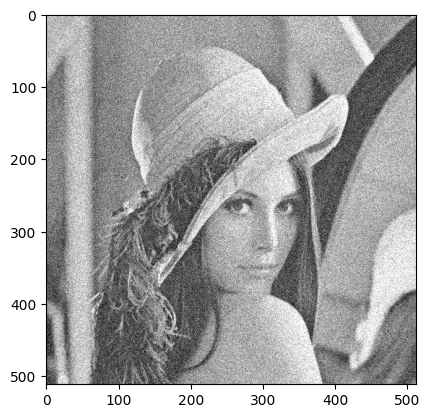

In [6]:
from skimage.util import random_noise

# 生成與影像相同大小的高斯雜訊
gaussian_noise = np.random.normal(20, 25, image.shape)

# 將雜訊加到影像上
noisy_image = image + gaussian_noise

# 限制像素值在 0-255 範圍內
noisy_image = np.clip(noisy_image, 0, 255)

plt.imshow(noisy_image, cmap="gray")

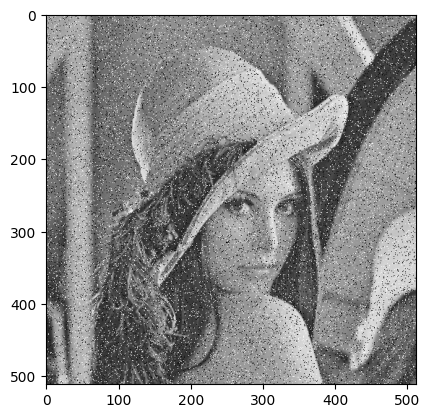

In [7]:
noisy_image = image.copy()
salt_prob = 0.05
pepper_prob = 0.05

# 生成隨機矩陣
random_matrix = np.random.random(image.shape[:2])

# 添加鹽雜訊(白點 = 255)
noisy_image[random_matrix < salt_prob] = 255

# 添加椒雜訊(黑點 = 0)
noisy_image[random_matrix > 1 - pepper_prob] = 0

plt.imshow(noisy_image, cmap="gray")

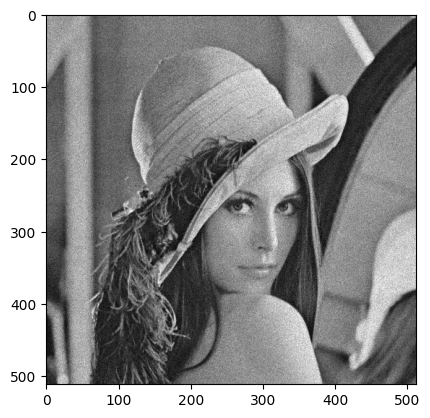

In [8]:
noisy = np.random.poisson(image)
noisy = np.clip(noisy, 0, 255)
plt.imshow(noisy, cmap="gray")

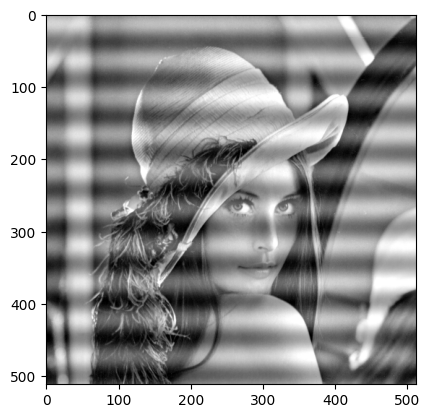

In [9]:
# 定義週期性雜訊參數
rows, cols = image.shape
A = 50             # 振幅
u0, v0 = 0, 10     # 垂直方向週期頻率（可調整觀察）

# 建立座標網格
x = np.arange(cols)
y = np.arange(rows)
X, Y = np.meshgrid(x, y)

# 生成週期性正弦雜訊
noise = A * np.sin(2 * np.pi * (u0 * X / cols + v0 * Y / rows))

# 將雜訊加入影像
noisy = image + noise
noisy = np.clip(noisy, 0, 255).astype(np.uint8)

plt.imshow(noisy, cmap="gray")